Create and Train a  model and 

1) Prepare data for training

In [12]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Load the breast cancer dataset
# cancer ve dictionary
cancer = load_breast_cancer()
print(cancer.keys())
# print(cancer.data)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


Convert list data to dataframe

In [13]:
# create dataframe
df = pd.DataFrame(cancer.data[:,0:2], columns=cancer.feature_names[0:2])
# add label column
df['class'] = cancer.target
print(df.sample(5, random_state=1))

     mean radius  mean texture  class
421        14.69         13.98      1
47         13.17         18.66      0
292        12.95         16.02      1
186        18.31         18.58      0
414        15.13         29.81      0


Convert label class from 0,1 to description

In [14]:
#  df['class'] = np.where(df['class'] == 0, 'malignant', 'benign')
#  df['class'] = np.where(df['class'] == 0, 'yes', 'no')

target = {0: 'malignant', 1: 'benign'}
df['class'] = df['class'].map(target)
print(df.sample(5, random_state=1))

     mean radius  mean texture      class
421        14.69         13.98     benign
47         13.17         18.66  malignant
292        12.95         16.02     benign
186        18.31         18.58  malignant
414        15.13         29.81  malignant


Check Null

In [15]:
df.isnull().sum()

mean radius     0
mean texture    0
class           0
dtype: int64

Visualization

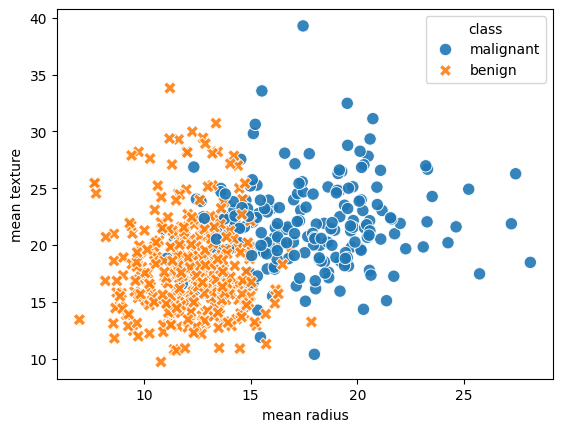

In [19]:
sns.scatterplot(x='mean radius', y='mean texture', hue='class', data=df, style='class',
                alpha=0.9, edgecolor='w' , s=80)
plt.show()

Label encoding

In [28]:
# encode label class
class_names, y = np.unique(df['class'], return_inverse=True)
# class_names type  : numpy.ndarray
# y type            : numpy.ndarray
print(class_names)
print(y[40:50])

['benign' 'malignant']
[1 1 1 1 1 1 0 1 0 0]


Prepare X

In [29]:
X = df.drop('class', axis=1)
X.sample(5, random_state=1)

,mean radius,mean texture
421,14.69,13.98
47,13.17,18.66
292,12.95,16.02
186,18.31,18.58
414,15.13,29.81


Standard Scale

In [31]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_sc = sc.fit_transform(X)
print(X_sc)

[[ 1.09706398 -2.07333501]
 [ 1.82982061 -0.35363241]
 [ 1.57988811  0.45618695]
 ...
 [ 0.70228425  2.0455738 ]
 [ 1.83834103  2.33645719]
 [-1.80840125  1.22179204]]


Visualization after standard scale

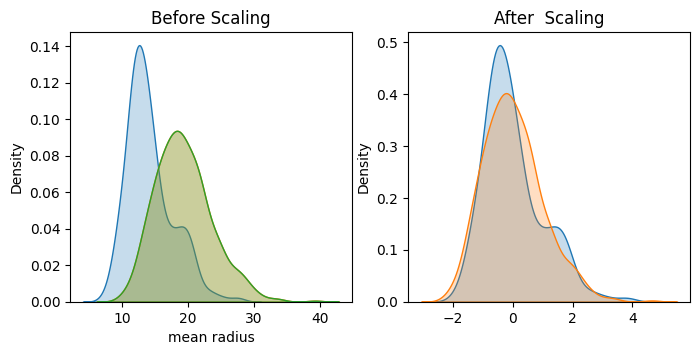

In [38]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 3.5))

ax1.set_title('Before Scaling')
sns.kdeplot(X['mean radius'], fill=True,ax=ax1)
sns.kdeplot(X['mean texture'], fill=True,ax=ax1)

ax2.set_title('After  Scaling')
sns.kdeplot(X_sc[:,0], fill=True, ax=ax2)
sns.kdeplot(X_sc[:,1], fill=True, ax=ax2)

sns.kdeplot(df['mean texture'], fill=True, ax=ax1)
plt.show()

plot data point

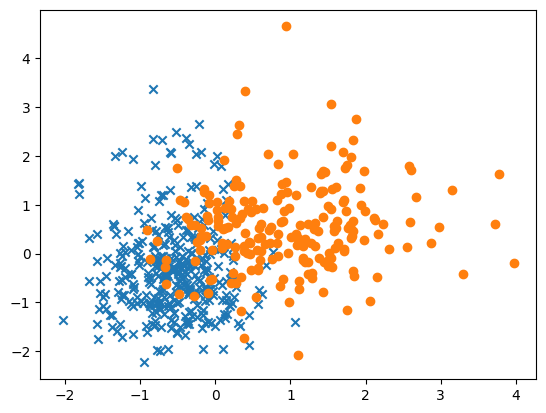

In [39]:
plt.scatter(X_sc[:,0][y==0], X_sc[:,1][y==0], label='malignant', marker='x')
plt.scatter(X_sc[:,0][y==1], X_sc[:,1][y==1], label='benign', marker='o')
plt.show()

Prepare Train data and test data

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_sc, y, test_size=0.25, random_state=1)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((426, 2), (143, 2), (426,), (143,))